
# Euler–Bernoulli Cantilever Beam — Two Hermite Beam Elements




## Problem definition and sign convention

A cantilever beam of length \(L\) is modeled with two equal Euler–Bernoulli beam elements,

$$
h_1=h_2=h=\frac{L}{2}.
$$

The distributed load varies linearly:

$$
q(x)=q_0\left(1-\frac{x}{L}\right).
$$

For the beam element, each node has two generalized degrees of freedom:

$$
\{U\}=
\begin{Bmatrix}
w\\
\theta
\end{Bmatrix},
\qquad
\theta=-\frac{dw}{dx}.
$$

Thus, for one element,

$$
\{U^e\}=
\begin{Bmatrix}
w_1 & \theta_1 & w_2 & \theta_2
\end{Bmatrix}^{T}.
$$

At the clamped end,

$$
w(0)=0,
\qquad
\theta(0)=0.
$$

The free-end generalized loads are introduced as

$$
Q_w(L)=F_0,
\qquad
Q_\theta(L)=-M_0.
$$

This is the sign convention used in the formulation below.


In [ ]:

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

sp.init_printing()

# Symbols
x, xi = sp.symbols('x xi', real=True)
L, h, EI = sp.symbols('L h EI', positive=True)
q0, F0, M0 = sp.symbols('q_0 F_0 M_0', real=True)

# For two equal elements
h_two = L/2



## Cubic Hermite interpolation

Let

$$
\xi=\frac{x-x_a}{h},
\qquad 0\le \xi\le 1,
$$

where \(x_a\) is the left end of the element.

Because the nodal rotational degree of freedom is defined here as

$$
\theta=-w',
$$

the Hermite interpolation is

$$
w^e(\xi)
=
\phi_1 w_1
+\phi_2\theta_1
+\phi_3w_2
+\phi_4\theta_2,
$$

with

$$
\phi_1=1-3\xi^2+2\xi^3,
$$

$$
\phi_2=-h(\xi-2\xi^2+\xi^3),
$$

$$
\phi_3=3\xi^2-2\xi^3,
$$

$$
\phi_4=h(\xi^2-\xi^3).
$$

These shape functions interpolate both displacement and slope information, which gives the $C^1$ continuity required by the Euler–Bernoulli beam formulation.



## Continuous element load vector

For the distributed load

$$
q(x)=q_0\left(1-\frac{x}{L}\right),
$$

the consistent element load vector is

$$
\{q^e\}
=
\int_{x_a}^{x_b}
q(x)\boldsymbol{\phi}(x)\,dx.
$$

Using

$$
x=x_a+h\xi,
$$

this becomes

$$
\{q^e\}
=
\int_0^1
q_0\left(1-\frac{x_a+h\xi}{L}\right)
\boldsymbol{\phi}(\xi)\,h\,d\xi.
$$


In [ ]:

xa = sp.symbols('x_a', real=True)

qx = q0 * (1 - (xa + h*xi)/L)

qe_general = sp.simplify(
    sp.integrate(phi * qx * h, (xi, 0, 1))
)

qe_general


⎡h⋅q₀⋅(10⋅L - 3⋅h - 10⋅xₐ)⎤
⎢─────────────────────────⎥
⎢          20⋅L           ⎥
⎢                         ⎥
⎢ 2                       ⎥
⎢h ⋅q₀⋅(-5⋅L + 2⋅h + 5⋅xₐ)⎥
⎢─────────────────────────⎥
⎢          60⋅L           ⎥
⎢                         ⎥
⎢h⋅q₀⋅(10⋅L - 7⋅h - 10⋅xₐ)⎥
⎢─────────────────────────⎥
⎢          20⋅L           ⎥
⎢                         ⎥
⎢ 2                       ⎥
⎢h ⋅q₀⋅(5⋅L - 3⋅h - 5⋅xₐ) ⎥
⎢──────────────────────── ⎥
⎣          60⋅L           ⎦


For the two-element mesh,

$$
h=\frac{L}{2}.
$$

The left coordinates of the elements are

$$
x_a^{(1)}=0,
\qquad
x_a^{(2)}=\frac{L}{2}.
$$

Therefore, the two consistent distributed-load vectors are obtained by simply substituting these values.


In [ ]:

qe1 = sp.simplify(qe_general.subs({h: L/2, xa: 0}))
qe2 = sp.simplify(qe_general.subs({h: L/2, xa: L/2}))

print("Element 1 distributed-load vector:")
display(qe1)

print("Element 2 distributed-load vector:")
display(qe2)


Element 1 distributed-load vector:


⎡17⋅L⋅q₀⎤
⎢───────⎥
⎢  80   ⎥
⎢       ⎥
⎢  2    ⎥
⎢-L ⋅q₀ ⎥
⎢───────⎥
⎢  60   ⎥
⎢       ⎥
⎢13⋅L⋅q₀⎥
⎢───────⎥
⎢  80   ⎥
⎢       ⎥
⎢   2   ⎥
⎢7⋅L ⋅q₀⎥
⎢───────⎥
⎣  480  ⎦

Element 2 distributed-load vector:


⎡7⋅L⋅q₀ ⎤
⎢────── ⎥
⎢  80   ⎥
⎢       ⎥
⎢  2    ⎥
⎢-L ⋅q₀ ⎥
⎢───────⎥
⎢  160  ⎥
⎢       ⎥
⎢3⋅L⋅q₀ ⎥
⎢────── ⎥
⎢  80   ⎥
⎢       ⎥
⎢  2    ⎥
⎢ L ⋅q₀ ⎥
⎢ ───── ⎥
⎣  240  ⎦


The results are

$$
\{q^{(1)}\}
=
\begin{Bmatrix}
\dfrac{17q_0L}{80}\\[4pt]
-\dfrac{q_0L^2}{60}\\[4pt]
\dfrac{13q_0L}{80}\\[4pt]
\dfrac{7q_0L^2}{480}
\end{Bmatrix},
$$

and

$$
\{q^{(2)}\}
=
\begin{Bmatrix}
\dfrac{7q_0L}{80}\\[4pt]
-\dfrac{q_0L^2}{160}\\[4pt]
\dfrac{3q_0L}{80}\\[4pt]
\dfrac{q_0L^2}{240}
\end{Bmatrix}.
$$

Notice that the element load vectors are not identical because $q(x)$ decreases with $x$.


In [ ]:

phi = sp.Matrix([
    1 - 3*xi**2 + 2*xi**3,
    -h*(xi - 2*xi**2 + xi**3),
    3*xi**2 - 2*xi**3,
    h*(xi**2 - xi**3)
])

phi


⎡    3      2      ⎤
⎢ 2⋅ξ  - 3⋅ξ  + 1  ⎥
⎢                  ⎥
⎢   ⎛ 3      2    ⎞⎥
⎢-h⋅⎝ξ  - 2⋅ξ  + ξ⎠⎥
⎢                  ⎥
⎢       3      2   ⎥
⎢  - 2⋅ξ  + 3⋅ξ    ⎥
⎢                  ⎥
⎢    ⎛   3    2⎞   ⎥
⎣  h⋅⎝- ξ  + ξ ⎠   ⎦


## Element stiffness matrix

For an Euler–Bernoulli beam,

$$
M=EI\frac{d^2w}{dx^2}.
$$

The element stiffness matrix is

$$
[K^e]
=
\int_{x_a}^{x_b}
EI
\left(\frac{d^2\boldsymbol{\phi}}{dx^2}\right)
\left(\frac{d^2\boldsymbol{\phi}}{dx^2}\right)^T
dx.
$$

Since

$$
x=x_a+h\xi,
\qquad
dx=h\,d\xi,
$$

we can evaluate the matrix directly in the parent coordinate \(\xi\).


In [ ]:

d2phi_dx2 = sp.diff(phi, xi, 2) / h**2

Ke = sp.simplify(
    EI * sp.integrate(d2phi_dx2 * d2phi_dx2.T * h, (xi, 0, 1))
)

Ke


⎡ 12⋅EI   -6⋅EI   -12⋅EI   -6⋅EI ⎤
⎢ ─────   ──────  ───────  ──────⎥
⎢   3        2       3        2  ⎥
⎢  h        h       h        h   ⎥
⎢                                ⎥
⎢-6⋅EI     4⋅EI    6⋅EI     2⋅EI ⎥
⎢──────    ────    ────     ──── ⎥
⎢   2       h        2       h   ⎥
⎢  h                h            ⎥
⎢                                ⎥
⎢-12⋅EI    6⋅EI    12⋅EI    6⋅EI ⎥
⎢───────   ────    ─────    ──── ⎥
⎢   3        2       3        2  ⎥
⎢  h        h       h        h   ⎥
⎢                                ⎥
⎢-6⋅EI     2⋅EI    6⋅EI     4⋅EI ⎥
⎢──────    ────    ────     ──── ⎥
⎢   2       h        2       h   ⎥
⎣  h                h            ⎦


The resulting matrix is

$$
[K^e]
=
\frac{EI}{h^3}
\begin{bmatrix}
12 & -6h & -12 & -6h\\
-6h & 4h^2 & 6h & 2h^2\\
-12 & 6h & 12 & 6h\\
-6h & 2h^2 & 6h & 4h^2
\end{bmatrix}.
$$

The signs associated with the rotational terms follow from the choice

$$
\theta=-w'.
$$



## Assemble the two elements

There are three global nodes and therefore six global degrees of freedom:

$$
\{U\}
=
\begin{Bmatrix}
w_1 & \theta_1 &
w_2 & \theta_2 &
w_3 & \theta_3
\end{Bmatrix}^{T}.
$$

Element connectivity:

- Element 1: global DOFs \([1,2,3,4]\)
- Element 2: global DOFs \([3,4,5,6]\)

The global stiffness matrix and load vector are obtained by the usual direct-stiffness assembly procedure.


In [ ]:

Ke_two = sp.simplify(Ke.subs(h, L/2))

K = sp.zeros(6, 6)
Q = sp.zeros(6, 1)

conn1 = [0, 1, 2, 3]
conn2 = [2, 3, 4, 5]

for a in range(4):
    Q[conn1[a], 0] += qe1[a]
    Q[conn2[a], 0] += qe2[a]
    for b in range(4):
        K[conn1[a], conn1[b]] += Ke_two[a, b]
        K[conn2[a], conn2[b]] += Ke_two[a, b]

K = sp.simplify(K)
Q = sp.simplify(Q)

print("Global stiffness matrix:")
display(K)

print("Global distributed-load vector:")
display(Q)


Global stiffness matrix:


⎡ 96⋅EI   -24⋅EI   -96⋅EI   -24⋅EI                   ⎤
⎢ ─────   ───────  ───────  ───────     0        0   ⎥
⎢   3        2        3        2                     ⎥
⎢  L        L        L        L                      ⎥
⎢                                                    ⎥
⎢-24⋅EI    8⋅EI     24⋅EI    4⋅EI                    ⎥
⎢───────   ────     ─────    ────       0        0   ⎥
⎢   2       L         2       L                      ⎥
⎢  L                 L                               ⎥
⎢                                                    ⎥
⎢-96⋅EI    24⋅EI   192⋅EI            -96⋅EI   -24⋅EI ⎥
⎢───────   ─────   ──────      0     ───────  ───────⎥
⎢   3        2        3                 3        2   ⎥
⎢  L        L        L                 L        L    ⎥
⎢                                                    ⎥
⎢-24⋅EI    4⋅EI              16⋅EI    24⋅EI    4⋅EI  ⎥
⎢───────   ────       0      ─────    ─────    ────  ⎥
⎢   2       L                  L        2       L    ⎥
⎢  L      

Global distributed-load vector:


⎡17⋅L⋅q₀⎤
⎢───────⎥
⎢  80   ⎥
⎢       ⎥
⎢  2    ⎥
⎢-L ⋅q₀ ⎥
⎢───────⎥
⎢  60   ⎥
⎢       ⎥
⎢ L⋅q₀  ⎥
⎢ ────  ⎥
⎢  4    ⎥
⎢       ⎥
⎢  2    ⎥
⎢ L ⋅q₀ ⎥
⎢ ───── ⎥
⎢  120  ⎥
⎢       ⎥
⎢3⋅L⋅q₀ ⎥
⎢────── ⎥
⎢  80   ⎥
⎢       ⎥
⎢  2    ⎥
⎢ L ⋅q₀ ⎥
⎢ ───── ⎥
⎣  240  ⎦


## Add the point force and end moment

At the free end, node 3, the generalized nodal loads are

$$
Q_5=F_0,
\qquad
Q_6=-M_0.
$$

Therefore,

$$
\{Q\}_{\text{total}}
=
\{Q\}_{q(x)}
+
\begin{Bmatrix}
0\\
0\\
0\\
0\\
F_0\\
-M_0
\end{Bmatrix}.
$$


In [ ]:
Q_total = sp.Matrix(Q)
Q_total[4] += F0
Q_total[5] += -M0

display(Q_total)

⎡  17⋅L⋅q₀  ⎤
⎢  ───────  ⎥
⎢    80     ⎥
⎢           ⎥
⎢    2      ⎥
⎢  -L ⋅q₀   ⎥
⎢  ───────  ⎥
⎢    60     ⎥
⎢           ⎥
⎢   L⋅q₀    ⎥
⎢   ────    ⎥
⎢    4      ⎥
⎢           ⎥
⎢    2      ⎥
⎢   L ⋅q₀   ⎥
⎢   ─────   ⎥
⎢    120    ⎥
⎢           ⎥
⎢     3⋅L⋅q₀⎥
⎢F₀ + ──────⎥
⎢       80  ⎥
⎢           ⎥
⎢ 2         ⎥
⎢L ⋅q₀      ⎥
⎢───── - M₀ ⎥
⎣ 240       ⎦


## Apply the clamped boundary conditions

At \(x=0\),

$$
w_1=0,
\qquad
\theta_1=0.
$$

Therefore, the unknown degrees of freedom are

$$
\{U_f\}
=
\begin{Bmatrix}
w_2 & \theta_2 & w_3 & \theta_3
\end{Bmatrix}^{T}.
$$

We reduce the global system to

$$
[K_{ff}]\{U_f\}=\{Q_f\}.
$$


In [ ]:

free = [2, 3, 4, 5]

Kff = K.extract(free, free)
Qf  = Q_total.extract(free, [0])

Uf = sp.simplify(Kff.inv() * Qf)

print("Unknown nodal DOFs [w2, theta2, w3, theta3]^T:")
display(Uf)


Unknown nodal DOFs [w2, theta2, w3, theta3]^T:


⎡ 2 ⎛               2            ⎞⎤
⎢L ⋅⎝400⋅F₀⋅L + 49⋅L ⋅q₀ + 480⋅M₀⎠⎥
⎢─────────────────────────────────⎥
⎢             3840⋅EI             ⎥
⎢                                 ⎥
⎢   ⎛              2           ⎞  ⎥
⎢ L⋅⎝-48⋅F₀⋅L - 5⋅L ⋅q₀ - 64⋅M₀⎠  ⎥
⎢ ──────────────────────────────  ⎥
⎢             128⋅EI              ⎥
⎢                                 ⎥
⎢   2 ⎛           2           ⎞   ⎥
⎢  L ⋅⎝10⋅F₀⋅L + L ⋅q₀ + 15⋅M₀⎠   ⎥
⎢  ────────────────────────────   ⎥
⎢             30⋅EI               ⎥
⎢                                 ⎥
⎢    ⎛            2           ⎞   ⎥
⎢  L⋅⎝-12⋅F₀⋅L - L ⋅q₀ - 24⋅M₀⎠   ⎥
⎢  ────────────────────────────   ⎥
⎣             24⋅EI               ⎦


The complete global displacement vector is

$$
\{U\}
=
\begin{Bmatrix}
0 & 0 & w_2 & \theta_2 & w_3 & \theta_3
\end{Bmatrix}^{T}.
$$


In [ ]:

U = sp.Matrix([0, 0, Uf[0], Uf[1], Uf[2], Uf[3]])
display(U)


⎡                0                ⎤
⎢                                 ⎥
⎢                0                ⎥
⎢                                 ⎥
⎢ 2 ⎛               2            ⎞⎥
⎢L ⋅⎝400⋅F₀⋅L + 49⋅L ⋅q₀ + 480⋅M₀⎠⎥
⎢─────────────────────────────────⎥
⎢             3840⋅EI             ⎥
⎢                                 ⎥
⎢   ⎛              2           ⎞  ⎥
⎢ L⋅⎝-48⋅F₀⋅L - 5⋅L ⋅q₀ - 64⋅M₀⎠  ⎥
⎢ ──────────────────────────────  ⎥
⎢             128⋅EI              ⎥
⎢                                 ⎥
⎢   2 ⎛           2           ⎞   ⎥
⎢  L ⋅⎝10⋅F₀⋅L + L ⋅q₀ + 15⋅M₀⎠   ⎥
⎢  ────────────────────────────   ⎥
⎢             30⋅EI               ⎥
⎢                                 ⎥
⎢    ⎛            2           ⎞   ⎥
⎢  L⋅⎝-12⋅F₀⋅L - L ⋅q₀ - 24⋅M₀⎠   ⎥
⎢  ────────────────────────────   ⎥
⎣             24⋅EI               ⎦


## Reconstruct the finite-element displacement field

For element 1,

$$
0\le x\le \frac{L}{2},
\qquad
\xi_1=\frac{x}{h}=\frac{2x}{L}.
$$

For element 2,

$$
\frac{L}{2}\le x\le L,
\qquad
\xi_2=\frac{x-L/2}{h}
=\frac{2x}{L}-1.
$$

The displacement within each element is obtained from

$$
w_h^e=\boldsymbol{\phi}^{T}\{U^e\}.
$$


In [ ]:

# Element nodal vectors
Ue1 = U.extract([0, 1, 2, 3], [0])
Ue2 = U.extract([2, 3, 4, 5], [0])

phi_h = phi.subs(h, L/2)

xi1 = 2*x/L
xi2 = 2*x/L - 1

w1_FE = sp.factor((phi_h.T * Ue1)[0].subs(xi, xi1))
w2_FE = sp.factor((phi_h.T * Ue2)[0].subs(xi, xi2))

print("FE displacement in element 1:")
display(w1_FE)

print("FE displacement in element 2:")
display(w2_FE)


FE displacement in element 1:


  2 ⎛                          2                        ⎞ 
-x ⋅⎝-240⋅F₀⋅L + 80⋅F₀⋅x - 36⋅L ⋅q₀ + 23⋅L⋅q₀⋅x - 240⋅M₀⎠ 
──────────────────────────────────────────────────────────
                          480⋅EI                          

FE displacement in element 2:


 ⎛            2          3      4          3           2     2           3     ↪
-⎝- 240⋅F₀⋅L⋅x  + 80⋅F₀⋅x  + 2⋅L ⋅q₀ - 13⋅L ⋅q₀⋅x - 8⋅L ⋅q₀⋅x  + 3⋅L⋅q₀⋅x  - 2 ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                         480⋅EI                                ↪

↪        2⎞ 
↪ 40⋅M₀⋅x ⎠ 
↪ ──────────
↪           


## Finite-element bending moment

For the sign convention used here, the curvature is

$$
\kappa=\frac{d^2w}{dx^2},
$$

and the bending-moment field associated with the displacement approximation is

$$
M_h(x)=EI\frac{d^2w_h}{dx^2}.
$$

Because the Hermite displacement interpolation is cubic within each element, the corresponding bending moment is linear within each element.


In [ ]:

M1_FE = sp.factor(EI * sp.diff(w1_FE, x, 2))
M2_FE = sp.factor(EI * sp.diff(w2_FE, x, 2))

print("FE moment in element 1:")
display(M1_FE)

print("FE moment in element 2:")
display(M2_FE)


FE moment in element 1:


 ⎛                         2                       ⎞ 
-⎝-80⋅F₀⋅L + 80⋅F₀⋅x - 12⋅L ⋅q₀ + 23⋅L⋅q₀⋅x - 80⋅M₀⎠ 
─────────────────────────────────────────────────────
                         80                          

FE moment in element 2:


 ⎛                          2                       ⎞ 
-⎝-240⋅F₀⋅L + 240⋅F₀⋅x - 8⋅L ⋅q₀ + 9⋅L⋅q₀⋅x - 240⋅M₀⎠ 
──────────────────────────────────────────────────────
                         240                          


## Exact solution

The Euler–Bernoulli governing equation is

$$
EI\,w^{(4)}(x)
=
q_0\left(1-\frac{x}{L}\right).
$$

The essential boundary conditions are

$$
w(0)=0,
\qquad
w'(0)=0.
$$

To remain consistent with the generalized free-end loads used in the finite-element equations,

$$
-EI\,w'''(L)=F_0,
$$

and

$$
-EI\,w''(L)=-M_0.
$$

The second condition is equivalent to

$$
EI\,w''(L)=M_0.
$$

We integrate the differential equation four times and determine the integration constants from these four boundary conditions.


In [ ]:

C1, C2, C3, C4 = sp.symbols('C1 C2 C3 C4')

w4 = q0*(1 - x/L)/EI
w3 = sp.integrate(w4, x) + C1
w2 = sp.integrate(w3, x) + C2
w1 = sp.integrate(w2, x) + C3
w_exact_general = sp.integrate(w1, x) + C4

eqs = [
    sp.Eq(w_exact_general.subs(x, 0), 0),
    sp.Eq(sp.diff(w_exact_general, x).subs(x, 0), 0),
    sp.Eq((-EI*sp.diff(w_exact_general, x, 3)).subs(x, L), F0),
    sp.Eq((EI*sp.diff(w_exact_general, x, 2)).subs(x, L), M0)
]

constants = sp.solve(eqs, [C1, C2, C3, C4], dict=True)[0]

w_exact = sp.factor(w_exact_general.subs(constants))
M_exact = sp.factor(EI * sp.diff(w_exact, x, 2))

print("Exact displacement:")
display(w_exact)

print("Exact bending moment:")
display(M_exact)


Exact displacement:


  2 ⎛         2                   3          2                          2      ↪
-x ⋅⎝- 60⋅F₀⋅L  + 20⋅F₀⋅L⋅x - 10⋅L ⋅q₀ + 10⋅L ⋅q₀⋅x - 60⋅L⋅M₀ - 5⋅L⋅q₀⋅x  + q₀ ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                     120⋅EI⋅L                                  ↪

↪   3⎞ 
↪ ⋅x ⎠ 
↪ ─────
↪      

Exact bending moment:


 ⎛        2               3         2                         2       3⎞ 
-⎝- 6⋅F₀⋅L  + 6⋅F₀⋅L⋅x - L ⋅q₀ + 3⋅L ⋅q₀⋅x - 6⋅L⋅M₀ - 3⋅L⋅q₀⋅x  + q₀⋅x ⎠ 
─────────────────────────────────────────────────────────────────────────
                                   6⋅L                                   


## Compare the finite-element and exact solutions



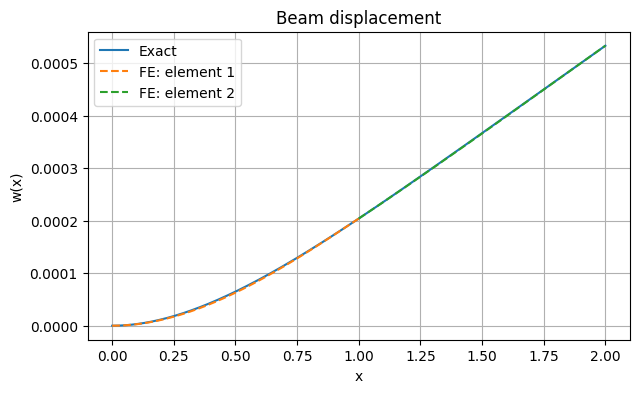

In [ ]:

# ---------------------------------------------------------
# EDIT THESE VALUES and check for yourself
# ---------------------------------------------------------
values = {
    L: 2.0,          # m
    EI: 1.0e6,       # N m^2
    q0: 1000.0,      # N/m
    F0: 0.0,         # N
    M0: 0.0           # N m
}

# Numerical functions
w1_fun = sp.lambdify(x, w1_FE.subs(values), 'numpy')
w2_fun = sp.lambdify(x, w2_FE.subs(values), 'numpy')
we_fun = sp.lambdify(x, w_exact.subs(values), 'numpy')

Lnum = float(values[L])

xx1 = np.linspace(0, Lnum/2, 150)
xx2 = np.linspace(Lnum/2, Lnum, 150)
xx  = np.linspace(0, Lnum, 300)

plt.figure(figsize=(7,4))
plt.plot(xx, we_fun(xx), label='Exact')
plt.plot(xx1, w1_fun(xx1), '--', label='FE: element 1')
plt.plot(xx2, w2_fun(xx2), '--', label='FE: element 2')
plt.xlabel('x')
plt.ylabel('w(x)')
plt.title('Beam displacement')
plt.grid(True)
plt.legend()
plt.show()


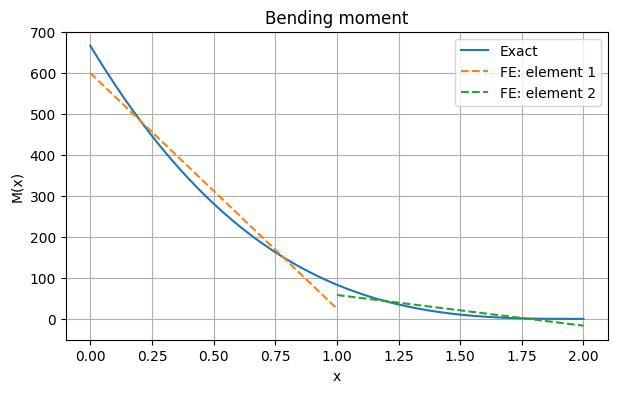

In [ ]:

M1_fun = sp.lambdify(x, M1_FE.subs(values), 'numpy')
M2_fun = sp.lambdify(x, M2_FE.subs(values), 'numpy')
Me_fun = sp.lambdify(x, M_exact.subs(values), 'numpy')

plt.figure(figsize=(7,4))
plt.plot(xx, Me_fun(xx), label='Exact')
plt.plot(xx1, M1_fun(xx1), '--', label='FE: element 1')
plt.plot(xx2, M2_fun(xx2), '--', label='FE: element 2')
plt.xlabel('x')
plt.ylabel('M(x)')
plt.title('Bending moment')
plt.grid(True)
plt.legend()
plt.show()
